Neural Networks
===============

Now we use DeepLearning Neural Networks to train and evalulate on the Chess-Board FEN String prediction.

Since the datasize is large, and we want to train and test on as much data as possible, I want to leverage the GPUs avaialable on my macbook pro max. Hence a new jupyter notebook for these models.

In [1]:
!python --version

Python 3.11.16


In [2]:
#All Imports
import os
import time
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import cv2
from pathlib import Path
from sklearn.metrics import precision_recall_fscore_support
import gc
from tensorflow.keras import backend as K

In [3]:
#GPU Check
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [4]:
#Define Constants
LOCAL_TRAIN_DIR = "/Users/mahidasp/Stanford-Courses/PythonTech-27/Project-Chess-FEN/Downsized-Dataset-200/train"
LOCAL_TEST_DIR = "/Users/mahidasp/Stanford-Courses/PythonTech-27/Project-Chess-FEN/Downsized-Dataset-200/test"
TRAINING_SIZE = 80000
TEST_IMAGES_SIZE = 20000
EPOCHS = 40
BATCH_SIZE = 32

In [5]:
# Helper Functions required to run all models in this Notebook
# ============================================================

def load_full_boards_to_ram(directory, max_images=None):
    start_time = time.time()
    image_files = [f for f in os.listdir(directory) if f.endswith(('.jpeg', '.jpg', '.png'))]
    if max_images:
        image_files = image_files[:max_images]

    num_images = len(image_files)
    print(f"Loading {num_images} images from {directory} into RAM...")

    # Pre-allocate float16 array (200x200x3)
    X = np.empty((num_images, 200, 200, 3), dtype=np.float16)
    y_fen = []

    for i, filename in enumerate(image_files):
        filepath = os.path.join(directory, filename)
        img = Image.open(filepath).convert('RGB')
        X[i] = np.array(img, dtype=np.float16) / 255.0

        # This is not necessary, we could keep "-" as the separator, but
        # industry convention seems to use "/" for row sepearation as that is
        # easy on eyes.
        fen = filename.split('.jpeg')[0].replace('-', '/')
        y_fen.append(fen)

        if (i + 1) % 5000 == 0:
            print(f"Loaded {i + 1}/{num_images} images...")

    print(f"Data loading complete in {time.time() - start_time:.2f} seconds.")
    print(f"Total RAM used: {X.nbytes / (1024**3):.2f} GB")
    return X, np.array(y_fen)

In [6]:
# Load all the Training Images

X_train, y_train_fen = load_full_boards_to_ram(LOCAL_TRAIN_DIR, max_images=TRAINING_SIZE)

Loading 80000 images from /Users/mahidasp/Stanford-Courses/PythonTech-27/Project-Chess-FEN/Downsized-Dataset-200/train into RAM...
Loaded 5000/80000 images...
Loaded 10000/80000 images...
Loaded 15000/80000 images...
Loaded 20000/80000 images...
Loaded 25000/80000 images...
Loaded 30000/80000 images...
Loaded 35000/80000 images...
Loaded 40000/80000 images...
Loaded 45000/80000 images...
Loaded 50000/80000 images...
Loaded 55000/80000 images...
Loaded 60000/80000 images...
Loaded 65000/80000 images...
Loaded 70000/80000 images...
Loaded 75000/80000 images...
Loaded 80000/80000 images...
Data loading complete in 56.28 seconds.
Total RAM used: 17.88 GB


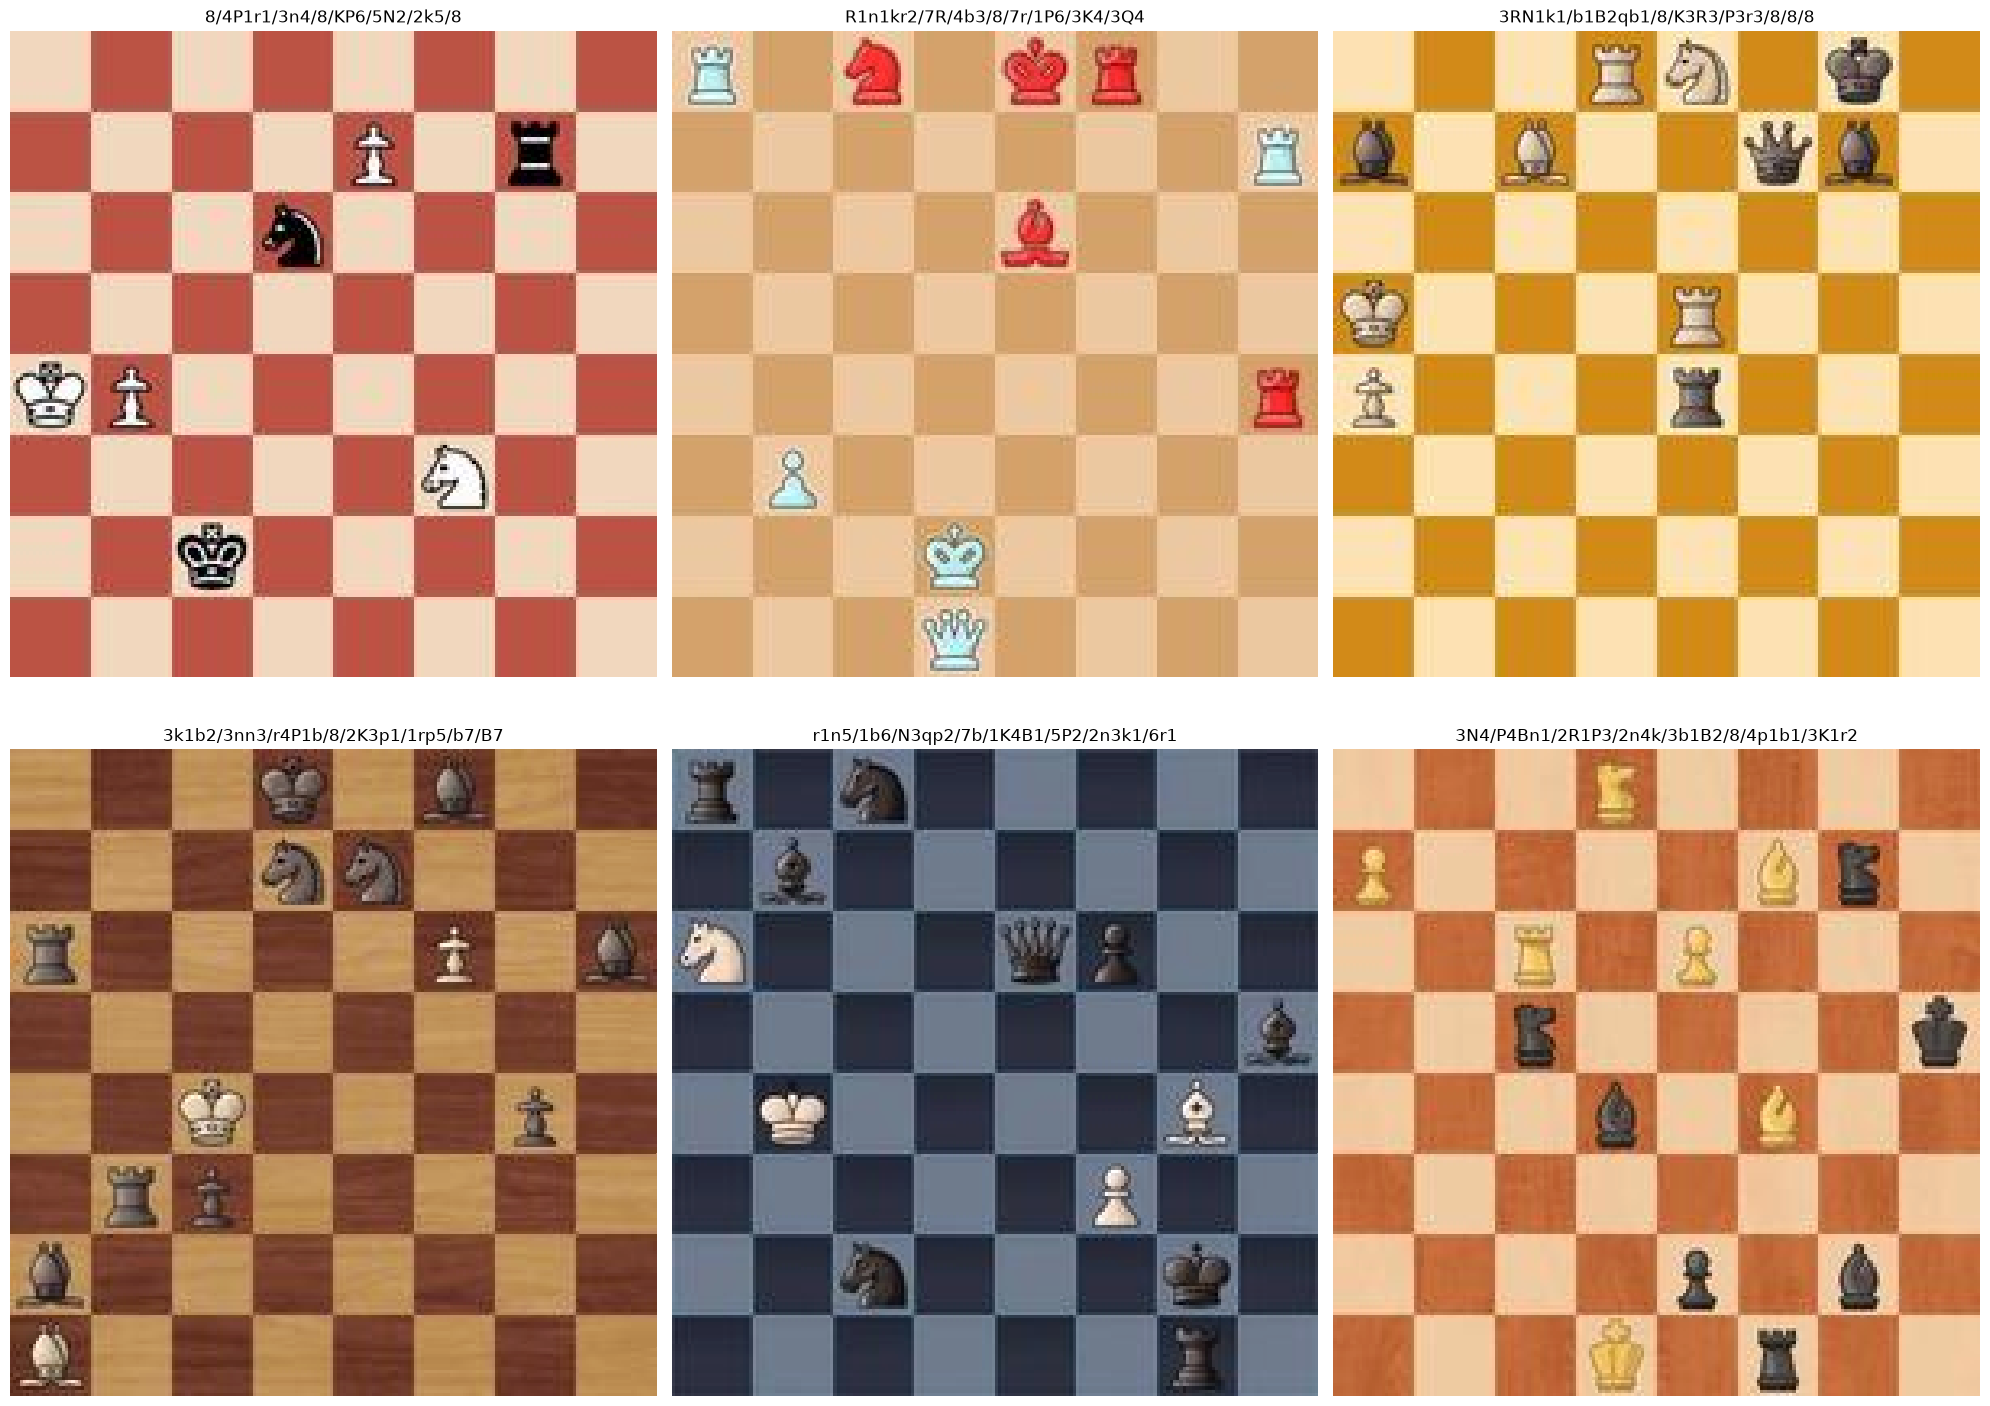

In [7]:
# Display random 6 images from the training set
random_indices = np.random.choice(len(X_train), 6, replace=False)

# Create a figure with 6 subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 15))
axes = axes.flatten()  # Flatten the axes array for easy indexing

for i, idx in enumerate(random_indices):
    # Get the flattened image array and its label
    img = X_train[idx]
    label = y_train_fen[idx]

    # Display the image and label
    axes[i].imshow(img)
    axes[i].set_title(label)
    axes[i].axis('off') # Hides the axis grid numbers

plt.tight_layout()
plt.show()

In [8]:
# mappings for easy handling
# 1. Define piece-to-integer mappings (13 classes)
PIECE_TO_INT = {
    'P': 0, 'R': 1, 'N': 2, 'B': 3, 'Q': 4, 'K': 5,  # White pieces
    'p': 6, 'r': 7, 'n': 8, 'b': 9, 'q': 10, 'k': 11, # Black pieces
    'empty': 12                                      # Empty square
}

INT_TO_PIECE = {v: k for k, v in PIECE_TO_INT.items()}
class_labels = [INT_TO_PIECE[i] for i in range(13)]

In [9]:
#Helper functions for FEN to lable (individual piece) conversion
def fen_to_labels(fen):
    """Expands a FEN string into an array of 64 integer class IDs."""
    labels = []
    board_part = fen.split()[0] # In case there are turn/castling tokens
    for row in board_part.split('/'):
        for char in row:
            if char.isdigit():
                labels.extend([PIECE_TO_INT['empty']] * int(char))
            else:
                labels.append(PIECE_TO_INT[char])
    return np.array(labels, dtype=np.int32)

def labels_to_fen_string(label_array):
    """Reconstructs standard FEN notation from 64 predicted integer labels."""
    rows = []
    for r in range(8):
        row_str = ""
        empty_count = 0
        for c in range(8):
            val = label_array[r * 8 + c]
            char = INT_TO_PIECE[val]
            if char == 'empty':
                empty_count += 1
            else:
                if empty_count > 0:
                    row_str += str(empty_count)
                    empty_count = 0
                row_str += char
        if empty_count > 0:
            row_str += str(empty_count)
        rows.append(row_str)
    return "/".join(rows)

In [10]:
# Convert all training FEN strings into a (TRAINING_SIZE, 64) target array
print(f'Encoding {TRAINING_SIZE} FEN strings to target labels...')
y_train_encoded = np.array([fen_to_labels(fen) for fen in y_train_fen], dtype=np.int32)
print(f"y_train_encoded shape: {y_train_encoded.shape}") # Should be (TRAINING_SIZE, 64)

Encoding 80000 FEN strings to target labels...
y_train_encoded shape: (80000, 64)


In [11]:
# Load the test images into RAM
X_test, y_test_fen = load_full_boards_to_ram(LOCAL_TEST_DIR, max_images=TEST_IMAGES_SIZE)

# 3. Encode the test FEN strings into integer labels
print(f"Encoding {len(y_test_fen)} test FEN strings...")
y_test_encoded = np.array([fen_to_labels(fen) for fen in y_test_fen], dtype=np.int32)
print(f"y_test_encoded shape: {y_test_encoded.shape}")
y_true_flat = y_test_encoded.flatten()

Loading 20000 images from /Users/mahidasp/Stanford-Courses/PythonTech-27/Project-Chess-FEN/Downsized-Dataset-200/test into RAM...
Loaded 5000/20000 images...
Loaded 10000/20000 images...
Loaded 15000/20000 images...
Loaded 20000/20000 images...
Data loading complete in 14.29 seconds.
Total RAM used: 4.47 GB
Encoding 20000 test FEN strings...
y_test_encoded shape: (20000, 64)


Multi-Layer-Perceptron Model
============================

Now we define a MLP with following architecture:
 - Input 200x200x3 , full board with RGB
 - Flatten the image into 200x200x3 = 120K Input values
 - Three Dense Fully Connected Hidden Layers 512 --> 256 --> 128
 - A Dense Multi-Ouput Layer for 64 squares x 13 possible outputs = 832
 - Use a Softmax layer for each of 64 squares to pic one out of the 13 , i.e. one with highest probability gets picked by softmax

In [12]:
# Define Full Chess-Board MLP model

def build_full_board_mlp(input_shape=(200, 200, 3), num_squares=64, num_classes=13):

    inputs = layers.Input(shape=input_shape, name="board_input")

    # 1. Flatten the entire 200x200x3 image (120,000 features)
    x = layers.Flatten(name="flatten_pixels")(inputs)

    # 2. Fully Connected Dense Layers (Standard MLP)
    x = layers.Dense(512, activation='relu', name="dense_1")(x)
    #x = layers.Dropout(0.2, name="dropout_1")(x)
    x = layers.Dropout(0.4, name="dropout_1")(x) # aggressive dropout

    x = layers.Dense(256, activation='relu', name="dense_2")(x)
    #x = layers.Dropout(0.2, name="dropout_2")(x)
    x = layers.Dropout(0.3, name="dropout_2")(x)


    x = layers.Dense(128, activation='relu', name="dense_3")(x)

    # 3. Output layer: 64 squares * 13 classes = 832 units
    x = layers.Dense(num_squares * num_classes, name="dense_logits")(x)

    # 4. Reshape into (64, 13) and apply Softmax over the 13 classes per square
    x = layers.Reshape((num_squares, num_classes), name="reshape_to_grid")(x)
    outputs = layers.Softmax(axis=-1, name="square_probabilities")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Full_Board_FEN_MLP")

    # Compile using Adam optimizer and Sparse Categorical Crossentropy
    model.compile(
        #optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [13]:
#Instantiate the Model
full_board_mlp = build_full_board_mlp()
full_board_mlp.summary()

2026-09-05 19:38:28.002990: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5 Max
2026-09-05 19:38:28.003030: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 128.00 GB
2026-09-05 19:38:28.003036: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 53.76 GB
2026-09-05 19:38:28.003092: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-05 19:38:28.003115: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "Full_Board_FEN_MLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 board_input (InputLayer)    [(None, 200, 200, 3)]     0         
                                                                 
 flatten_pixels (Flatten)    (None, 120000)            0         
                                                                 
 dense_1 (Dense)             (None, 512)               61440512  
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 128)        

In [14]:
# Because base  model's validation loss shot up from 65 in epoch 1 to 800 in epoch 40,
# let's try to adjust the learning rate so model does not swing.
# Create callbacks to dynamically adjust learning rate and stop early if it plateaus
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # Cut learning rate in half
    patience=4,       # If no improvement for 4 epochs
    verbose=1,
    min_lr=1e-6
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,      # Stop completely if no improvement for 10 epochs
    restore_best_weights=True # Keep the best version, not the last version
)


In [15]:
# Now lets train the model

history_mlp = full_board_mlp.fit(
    X_train,
    y_train_encoded,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,  # Uses 10% for validation
    shuffle=True,
    callbacks=[lr_scheduler, early_stopping]
)

Epoch 1/40
   6/2250 [..............................] - ETA: 23s - loss: 65.2078 - accuracy: 0.2134 

2026-09-05 19:38:52.968092: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-09-05 19:38:52.981273: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


2250/2250 [==============================] - 26s 11ms/step - loss: 30.6305 - accuracy: 0.7135 - val_loss: 39.7532 - val_accuracy: 0.4232 - lr: 5.0000e-04
Epoch 2/40
2250/2250 [==============================] - 23s 10ms/step - loss: 21.5090 - accuracy: 0.7197 - val_loss: 41.7120 - val_accuracy: 0.2759 - lr: 5.0000e-04
Epoch 3/40
2250/2250 [==============================] - 23s 10ms/step - loss: 25.5787 - accuracy: 0.7183 - val_loss: 34.2569 - val_accuracy: 0.5630 - lr: 5.0000e-04
Epoch 4/40
2250/2250 [==============================] - 23s 10ms/step - loss: 47.4070 - accuracy: 0.7143 - val_loss: 37.7035 - val_accuracy: 0.7516 - lr: 5.0000e-04
Epoch 5/40
2250/2250 [==============================] - 23s 10ms/step - loss: 71.3516 - accuracy: 0.7135 - val_loss: 48.0068 - val_accuracy: 0.8409 - lr: 5.0000e-04
Epoch 6/40
2250/2250 [==============================] - 23s 10ms/step - loss: 82.7428 - accuracy: 0.7133 - val_loss: 95.4189 - val_accuracy: 0.6521 - lr: 5.0000e-04
Epoch 7/40
2246/2250 

In [16]:
# 4. Evaluate the trained MLP on the unseen test data
print("\nEvaluating MLP on test dataset...")
test_loss, test_accuracy = full_board_mlp.evaluate(X_test, y_test_encoded, batch_size=64)
print(f"\nFinal Test Accuracy (MLP): {test_accuracy * 100:.2f}%")

#5 Generate Predictions for Confusion-Matrix
print("\nGenerating piece-by-piece predictions for Confusion Matrix...")
y_pred_probs = full_board_mlp.predict(X_test, batch_size=64)
y_pred_classes = np.argmax(y_pred_probs, axis=-1)
y_pred_flat = y_pred_classes.flatten()


Evaluating MLP on test dataset...
313/313 [==============================] - 2s 7ms/step - loss: 34.4023 - accuracy: 0.5628

Final Test Accuracy (MLP): 56.28%

Generating piece-by-piece predictions for Confusion Matrix...
313/313 [==============================] - 2s 5ms/step


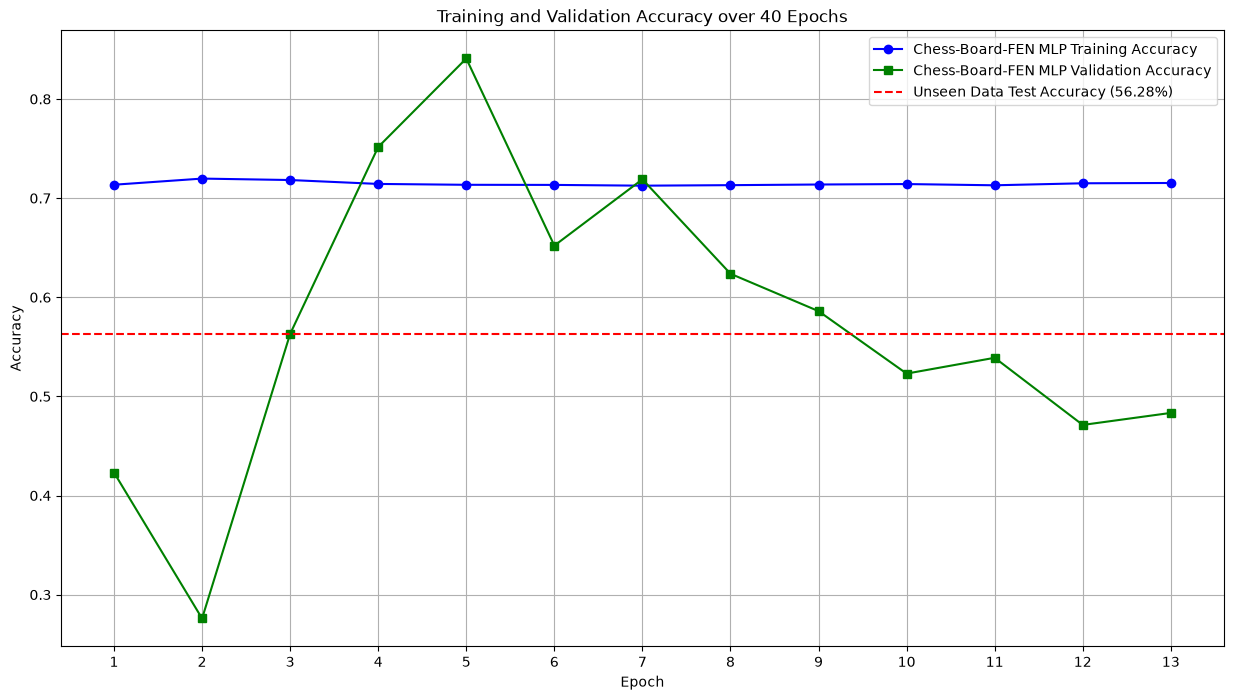

Final Recorded Test Accuracy for MLP: 56.28%


In [23]:
# Let's plot the accuracy over Epochs curve

plt.figure(figsize=(15, 8))

actual_epochs = len(history_mlp.history["accuracy"])
epochs = range(1, actual_epochs + 1)
plt.plot(
    epochs,
    history_mlp.history["accuracy"],
    "b-o",
    label="Chess-Board-FEN MLP Training Accuracy"
)
plt.plot(
    epochs,
    history_mlp.history["val_accuracy"],
    "g-s",
    label="Chess-Board-FEN MLP Validation Accuracy"
)

# The final test accuracy as a horizontal red dashed line
plt.axhline(
    y=test_accuracy,
    color='r',
    linestyle='--',
    label=f"Unseen Data Test Accuracy ({test_accuracy*100:.2f}%)"
)

plt.title(f"Training and Validation Accuracy over {EPOCHS} Epochs") # Updated title
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show() # Ensure plot is shown

# Print summary recorded accuracies
print(f"Final Recorded Test Accuracy for MLP: {test_accuracy * 100:.2f}%")

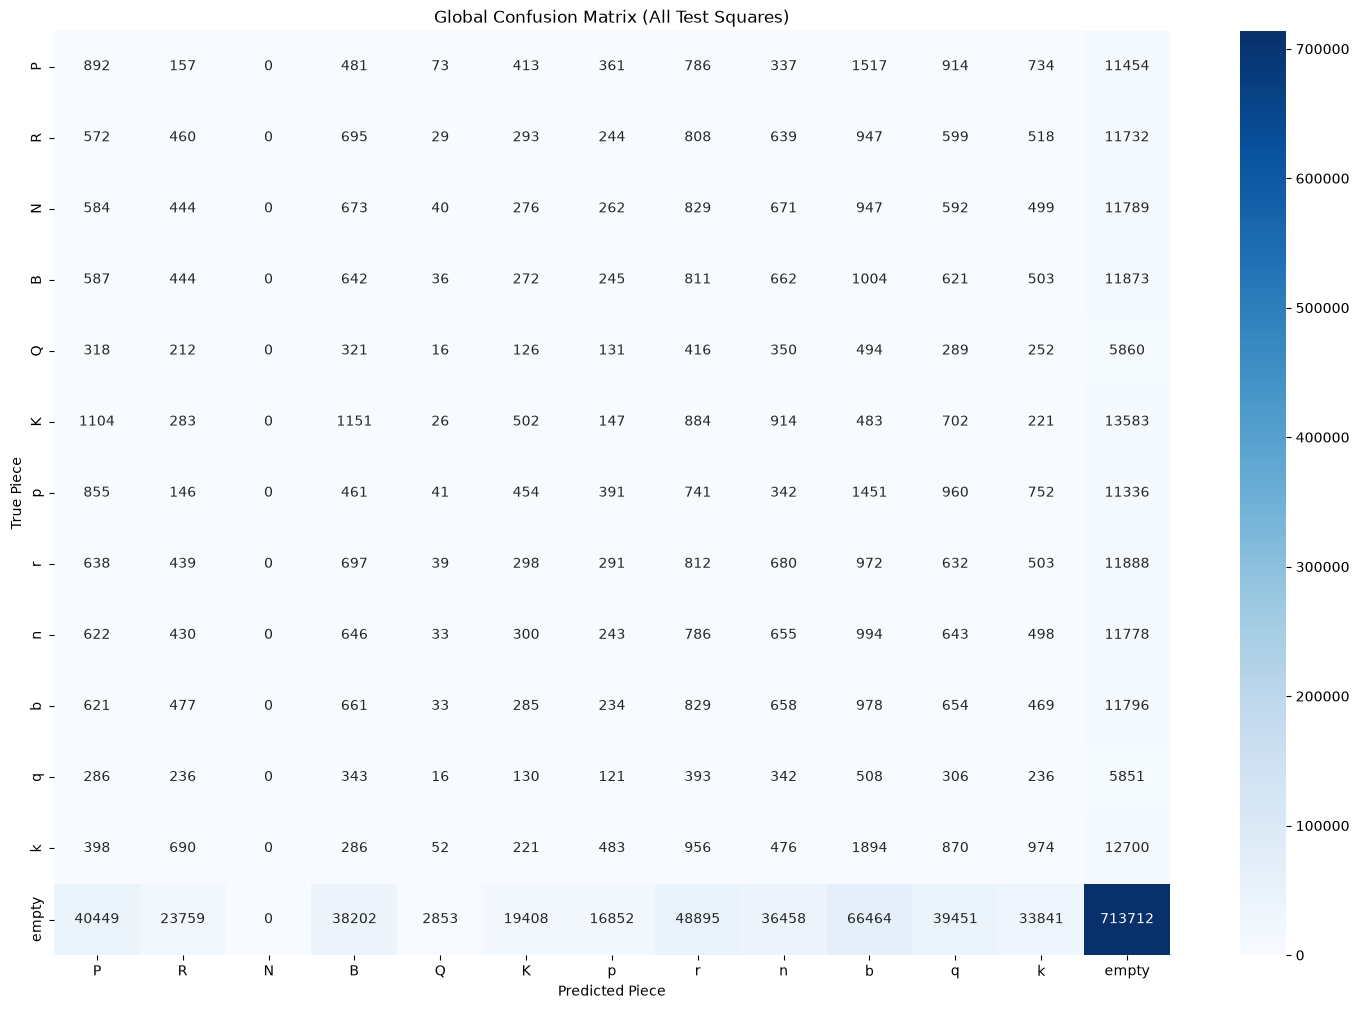


--- Per-Piece Accuracy Breakdown ---
     P :  4.92%  (   892 /  18119)
     R :  2.62%  (   460 /  17536)
     N :  0.00%  (     0 /  17606)
     B :  3.63%  (   642 /  17700)
     Q :  0.18%  (    16 /   8785)
     K :  2.51%  (   502 /  20000)
     p :  2.18%  (   391 /  17930)
     r :  4.54%  (   812 /  17889)
     n :  3.72%  (   655 /  17628)
     b :  5.53%  (   978 /  17695)
     q :  3.49%  (   306 /   8768)
     k :  4.87%  (   974 /  20000)
 empty : 66.06%  (713712 / 1080344)


In [21]:
# Generate and Plot the confusion matrix
cm = confusion_matrix(y_true_flat, y_pred_flat)
plt.figure(figsize=(18, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.title('Global Confusion Matrix (All Test Squares)')
plt.xlabel('Predicted Piece')
plt.ylabel('True Piece')
plt.show()
print("\n--- Per-Piece Accuracy Breakdown ---")
# The diagonal contains the correct predictions for each class
correct_per_class = cm.diagonal()
# Summing across the rows gives the total actual instances of each class
total_per_class = cm.sum(axis=1)

#print per-piece accuracy
for idx, piece in enumerate(class_labels):
    if total_per_class[idx] > 0:
        acc = (correct_per_class[idx] / total_per_class[idx]) * 100
        # Format the output for clean alignment
        print(f"{piece:>6} : {acc:5.2f}%  ({correct_per_class[idx]:>6} / {total_per_class[idx]:>6})")
    else:
        print(f"{piece:>6} : N/A (0 instances in test set)")

In [22]:
# Let's try to clear some memory we dont need for next model
try:
    del y_pred_probs
except NameError:
    pass

# 2. Clear TensorFlow's internal graph state
K.clear_session()

# 3. Force Python to run garbage collection and free the RAM
gc.collect()

print("Memory cleared!")

Memory cleared!


Summary of MLP Model
====================

The Confusion-Matrix , and the per-piece accuracy gives a better picture - in fact it paints an entirely different picture. We can see that most of the accuracy in our model is coming from predicting the 'empty' square.  The thing is, even with the board is fully occupied, if the model predicts 'empty' for every square, it's going to be 50% accurate (no different from a coin toss!!); with board sparsely populated, we can see that almost all of the prediction correctness is coming from the model simply predicting 'empty'.

I'm at least now convinced that MLP is not the right model for this Chess-Board FEN problem!!

Convolutional Neural Network Model
==================================

Having conviinced ourselves that MLP is not the correct model for our Chess-Board FEN, let's use a CNN to see how it performs.

In [24]:
def build_full_board_cnn(input_shape=(200, 200, 3), num_squares=64, num_classes=13):

    inputs = layers.Input(shape=input_shape, name="board_input")

    # 1. Convolutional Feature Extraction (The "Eyes" of the network)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # 2. Flatten for dense logic
    x = layers.Flatten()(x)

    # 3. Dense logic layers
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # 4. Multi-Output prediction (64 squares * 13 classes)
    x = layers.Dense(num_squares * num_classes, name="dense_logits")(x)
    x = layers.Reshape((num_squares, num_classes), name="reshape_to_grid")(x)
    outputs = layers.Softmax(axis=-1, name="square_probabilities")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Full_Board_CNN")

    # Using legacy Adam optimizer to avoid the M-series GPU Grappler
    # warning (thanks Google!)
    model.compile(
        optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=5e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [25]:
# Build and summarize
cnn_model = build_full_board_cnn()
cnn_model.summary()

Model: "Full_Board_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 board_input (InputLayer)    [(None, 200, 200, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 200, 200, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 100, 100, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 100, 100, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 50, 50, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 50, 50, 128)    

In [27]:
# Early stopping callback - Just like the one we had for MLP
early_stopping_cnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# Convert to memory-efficient datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train_encoded))
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Train the CNN
print("\nTraining CNN...")
"""
history_cnn = cnn_model.fit(
    X_train,
    y_train_encoded,
    epochs=20,
    batch_size=BATCH_SIZE,
    validation_split=0.05,
    shuffle=True,
    callbacks=[early_stopping_cnn]
)
"""
# Pass train_dataset for memory efficiency
history_cnn = cnn_model.fit(
    train_dataset,
    epochs=20,
    callbacks=[early_stopping_cnn]
)


Training CNN...
Epoch 1/20
2500/2500 [==============================] - ETA: 0s - loss: 0.4181 - accuracy: 0.8876WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,accuracy


2500/2500 [==============================] - 149s 59ms/step - loss: 0.4181 - accuracy: 0.8876
Epoch 2/20
2500/2500 [==============================] - ETA: 0s - loss: 0.2013 - accuracy: 0.9381WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,accuracy


2500/2500 [==============================] - 149s 60ms/step - loss: 0.2013 - accuracy: 0.9381
Epoch 3/20
2500/2500 [==============================] - ETA: 0s - loss: 0.1371 - accuracy: 0.9573WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,accuracy


2500/2500 [==============================] - 148s 59ms/step - loss: 0.1371 - accuracy: 0.9573
Epoch 4/20
2500/2500 [==============================] - ETA: 0s - loss: 0.0912 - accuracy: 0.9716WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,accuracy


2500/2500 [==============================] - 148s 59ms/step - loss: 0.0912 - accuracy: 0.9716
Epoch 5/20
2500/2500 [==============================] - ETA: 0s - loss: 0.0683 - accuracy: 0.9791WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,accuracy


...

2500/2500 [==============================] - 147s 59ms/step - loss: 0.0211 - accuracy: 0.9942
Epoch 17/20
2500/2500 [==============================] - ETA: 0s - loss: 0.0194 - accuracy: 0.9947WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,accuracy


2500/2500 [==============================] - 147s 59ms/step - loss: 0.0194 - accuracy: 0.9947
Epoch 18/20
2500/2500 [==============================] - ETA: 0s - loss: 0.0195 - accuracy: 0.9948WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,accuracy


2500/2500 [==============================] - 147s 59ms/step - loss: 0.0195 - accuracy: 0.9948
Epoch 19/20
2500/2500 [==============================] - ETA: 0s - loss: 0.0200 - accuracy: 0.9949WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,accuracy


2500/2500 [==============================] - 147s 59ms/step - loss: 0.0200 - accuracy: 0.9949
Epoch 20/20
2500/2500 [==============================] - ETA: 0s - loss: 0.0191 - accuracy: 0.9952WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,accuracy


2500/2500 [==============================] - 147s 59ms/step - loss: 0.0191 - accuracy: 0.9952


In [30]:
# 4. Evaluate the trained MLP on the unseen test data
print("\nEvaluating CNN on test dataset...")
test_loss_cnn, test_accuracy_cnn = cnn_model.evaluate(X_test, y_test_encoded, batch_size=BATCH_SIZE)
print(f"\nFinal Test Accuracy (CNN): {test_accuracy_cnn * 100:.2f}%")

#5 Generate Predictions for Confusion-Matrix
print("\nGenerating piece-by-piece predictions for Confusion Matrix...")
y_pred_probs_cnn = cnn_model.predict(X_test, batch_size=64)
y_pred_classes_cnn = np.argmax(y_pred_probs_cnn, axis=-1)
#y_true_flat_cnn = y_test_encoded.flatten()
y_pred_flat_cnn = y_pred_classes_cnn.flatten()


Evaluating CNN on test dataset...
625/625 [==============================] - 9s 14ms/step - loss: 0.0048 - accuracy: 0.9987

Final Test Accuracy (CNN): 99.87%

Generating piece-by-piece predictions for Confusion Matrix...
313/313 [==============================] - 8s 26ms/step


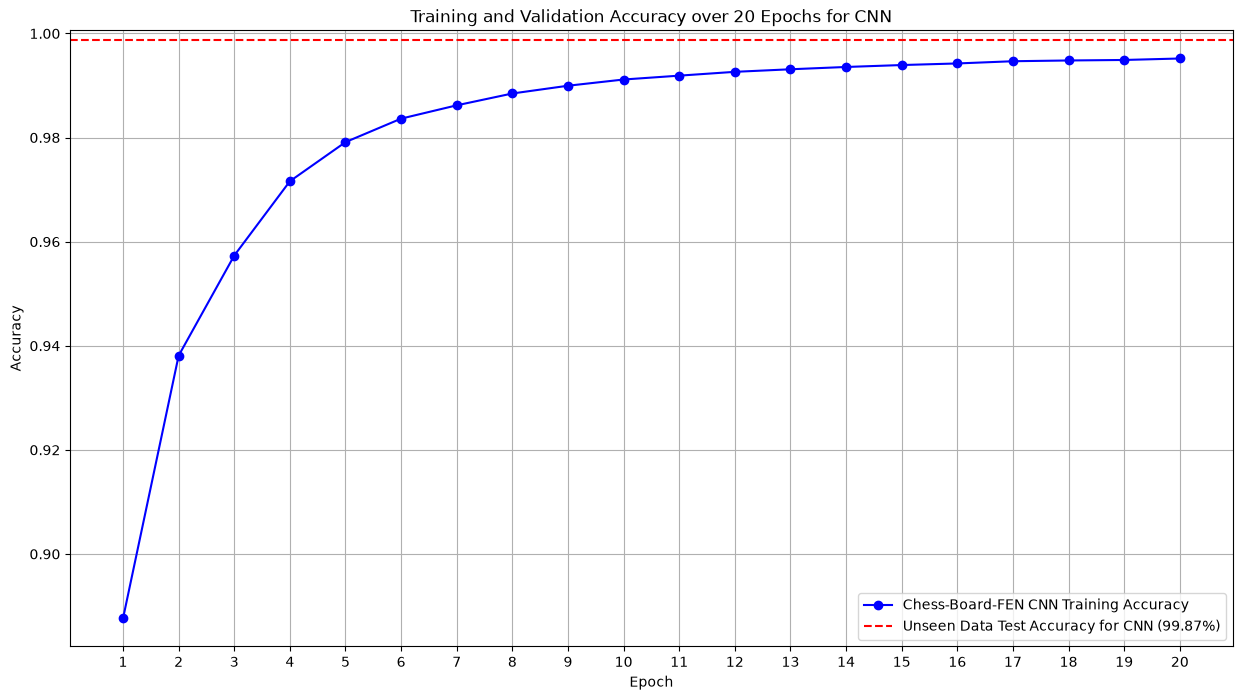

Final Recorded Test Accuracy: 99.87%


In [32]:
# Let's plot the accuracy over Epochs curve

plt.figure(figsize=(15, 8))

actual_epochs_cnn = len(history_cnn.history["accuracy"])
epochs_cnn = range(1, actual_epochs_cnn + 1)
plt.plot(
    epochs_cnn,
    history_cnn.history["accuracy"],
    "b-o",
    label="Chess-Board-FEN CNN Training Accuracy"
)
"""
plt.plot(
    epochs_cnn,
    history_cnn.history["val_accuracy"],
    "g-s",
    label="Chess-Board-FEN CNN Validation Accuracy"
)
"""

# The final test accuracy as a horizontal red dashed line
plt.axhline(
    y=test_accuracy_cnn,
    color='r',
    linestyle='--',
    label=f"Unseen Data Test Accuracy for CNN ({test_accuracy_cnn*100:.2f}%)"
)

plt.title(f"Training and Validation Accuracy over {actual_epochs_cnn} Epochs for CNN") # Updated title
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs_cnn)
plt.legend()
plt.grid(True)
plt.show() # Ensure plot is shown

# Print summary recorded accuracies
print(f"Final Recorded Test Accuracy: {test_accuracy_cnn * 100:.2f}%")

Observation:
============

The Unseen Data Test accuracy is higher than the Training accuracy and the Validation accuracy. I checked and read the literature - the answer I got ist that, with a high Dropouts we used in our model (recall 30% Dropout in the 512 Dense Layer, this is expected. The Dropouts deliberately drop the learnings/weights to avoid memorization.

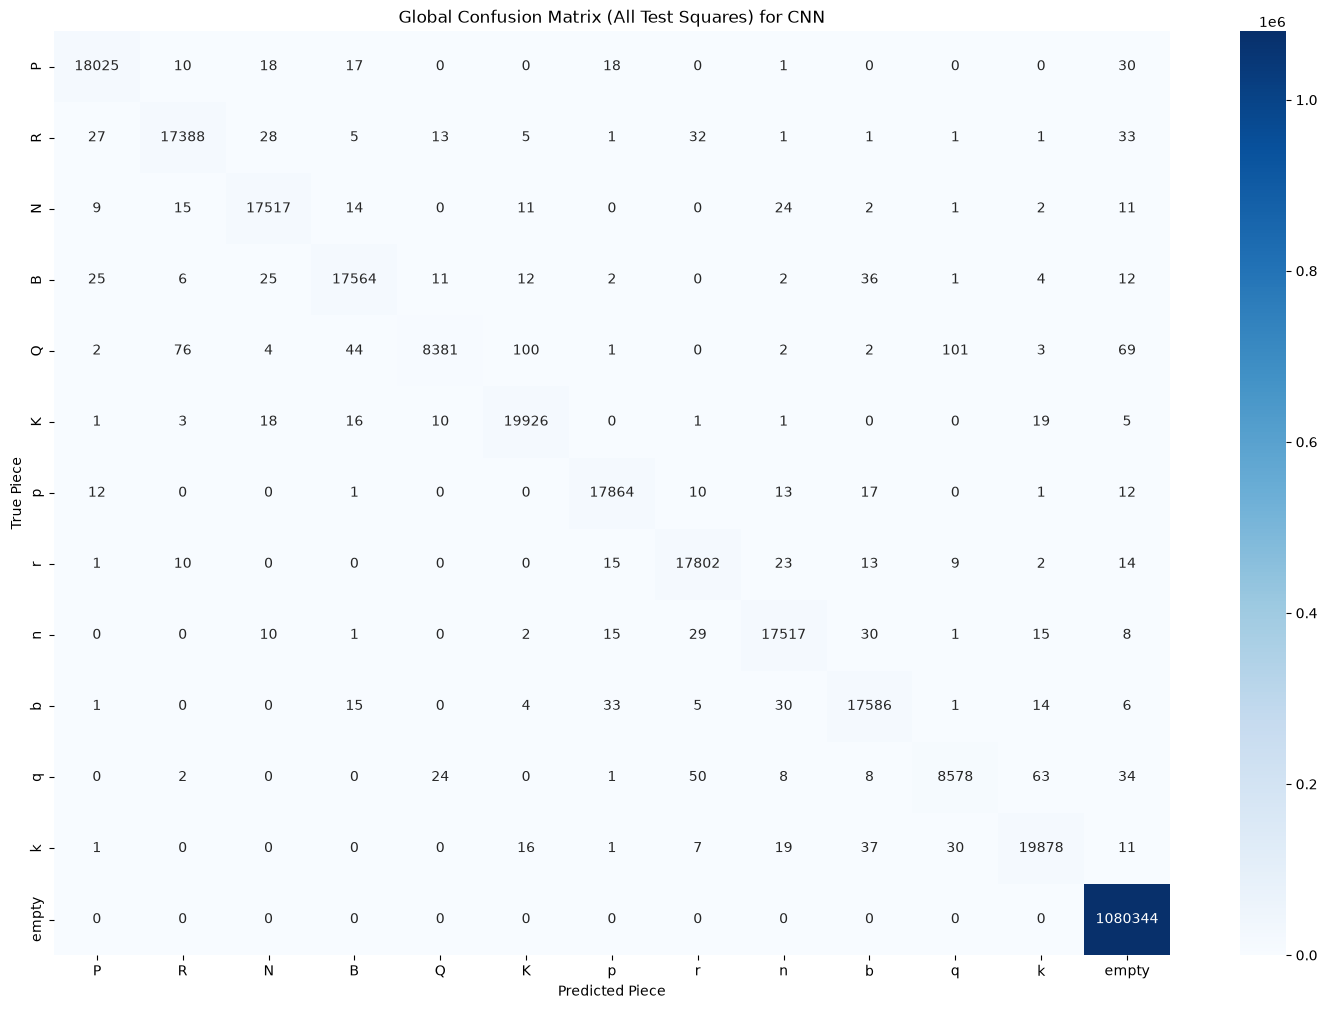


--- Per-Piece Accuracy Breakdown ---
     P : 99.48%  ( 18025 /  18119)
     R : 99.16%  ( 17388 /  17536)
     N : 99.49%  ( 17517 /  17606)
     B : 99.23%  ( 17564 /  17700)
     Q : 95.40%  (  8381 /   8785)
     K : 99.63%  ( 19926 /  20000)
     p : 99.63%  ( 17864 /  17930)
     r : 99.51%  ( 17802 /  17889)
     n : 99.37%  ( 17517 /  17628)
     b : 99.38%  ( 17586 /  17695)
     q : 97.83%  (  8578 /   8768)
     k : 99.39%  ( 19878 /  20000)
 empty : 100.00%  (1080344 / 1080344)


In [33]:
# Generate and Plot the confusion matrix for CNN Model
cm_cnn = confusion_matrix(y_true_flat, y_pred_flat_cnn)
plt.figure(figsize=(18, 12))
class_labels = [INT_TO_PIECE[i] for i in range(13)]
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.title('Global Confusion Matrix (All Test Squares) for CNN')
plt.xlabel('Predicted Piece')
plt.ylabel('True Piece')
plt.show()
print("\n--- Per-Piece Accuracy Breakdown ---")
# The diagonal contains the correct predictions for each class
correct_per_class = cm_cnn.diagonal()
# Summing across the rows gives the total actual instances of each class
total_per_class = cm_cnn.sum(axis=1)

#print per-piece accuracy
for idx, piece in enumerate(class_labels):
    if total_per_class[idx] > 0:
        acc = (correct_per_class[idx] / total_per_class[idx]) * 100
        # Format the output for clean alignment
        print(f"{piece:>6} : {acc:5.2f}%  ({correct_per_class[idx]:>6} / {total_per_class[idx]:>6})")
    else:
        print(f"{piece:>6} : N/A (0 instances in test set)")

In [34]:
# Let's clean up some memory not required for next model
try:
    del y_pred_probs_cnn
except NameError:
    pass

# 2. Clear TensorFlow's internal graph state
K.clear_session()

# 3. Force Python to run garbage collection and free the RAM
gc.collect()

print("CNN Model: Memory cleared!")

CNN Model: Memory cleared!


CNN Model Performance Notes
===========================

Ok, now looking at the overall accuracy, and the per-piece accuracy, this is way way way better than MLP.  Good thing is, the prediction for all th 12 Pieces looks good ~99+%, except queens that are getting mixed for color and for King a bit !!

Advanced CNN Model for Realworld Images
=======================================

In this, I hope to make the CNN model more robust to realworld images that may have shadows, lighting differences, different colors.  Additonally, the image presented may have additional objects such as border lines, different color combiniation for white v/s black squares and pieces, etc.  
Investing what's the best way to deal with these, Google suggested that I should do 'Data Agumentation' during training, which in essence artificially messes up the perfectly cropped training dataset images , so that the model can learn to deal with imperfections.  This is an area I need to understand more, but here I'm attempting to make some progress with few experimentations (with the help of Google, of course).

In [35]:
def build_advanced_cnn(input_shape=(200, 200, 3), num_squares=64, num_classes=13):

    inputs = layers.Input(shape=input_shape, name="board_input")

    #  Data Augmentation Block --- Not USED
    # These layers only active during training.
    # They pass the image through untouched during evaluation/prediction.
    #x = layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1))(inputs) # Randomly zoom in/out 10%
    #x = layers.RandomTranslation(height_factor=0.05, width_factor=0.05)(x) # Randomly shift the board up/down/left/right 5%
    #x = layers.RandomBrightness(factor=0.2)(inputs) # Randomly make the image 20% brighter or darker
    #x = layers.RandomContrast(factor=0.2)(x)

    # Block-1 stage now connects to the augmented 'x' instead of 'inputs'
    # We also added BatchNormalization if all of these convolution steps
    #x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
    #x = layers.BatchNormalization()(x)
    #x = layers.Activation('relu')(x)
    #x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2 - similar to prev CNN model
    #x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    #x = layers.BatchNormalization()(x)
    #x = layers.Activation('relu')(x)
    #x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3 - similar to prev CNN model
    #x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
    #x = layers.BatchNormalization()(x)
    #x = layers.Activation('relu')(x)
    #x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4 (New!) - 256 filters for deeper feature extraction
    #x = layers.Conv2D(256, (3, 3), padding='same', use_bias=False)(x)
    #x = layers.BatchNormalization()(x)
    #x = layers.Activation('relu')(x)
    #x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Flatten
    x = layers.Flatten()(x)

    # Dense Logic (Expanded to 1024 neurons to handle the extra filters)
    #x = layers.Dense(1024, use_bias=False)(x)
    #x = layers.BatchNormalization()(x)
    #x = layers.Activation('relu')(x)
    #x = layers.Dropout(0.4)(x) # Slightly higher dropout for better generalization
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.4)(x) # Keeps the model from simply memorizing the dataset

    # Multi-Output prediction
    x = layers.Dense(num_squares * num_classes, name="dense_logits")(x)
    x = layers.Reshape((num_squares, num_classes), name="reshape_to_grid")(x)
    outputs = layers.Softmax(axis=-1, name="square_probabilities")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Advanced_Board_CNN")

    # Because of Batch Normalization, we can safely bump the learning rate to 1e-3
    model.compile(
        optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=5e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [36]:
# Build and check the summary
adv_cnn = build_advanced_cnn()
adv_cnn.summary()

Model: "Advanced_Board_CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 board_input (InputLayer)    [(None, 200, 200, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 200, 200, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 100, 100, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 100, 100, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 50, 50, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 50, 50, 128)

Ok, next 4 cells are copy of the ones from earlier CNN, with just the variables renamed for 'advanced cnn'

In [37]:
# Early stopping callback for Advanced CNN
early_stopping_adv = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# Train the Advanced CNN
print("\nTraining Advanced CNN...")
history_adv = adv_cnn.fit(
    X_train,
    y_train_encoded,
    epochs=20,
    batch_size=BATCH_SIZE,
    validation_split=0.05,
    shuffle=True,
    callbacks=[early_stopping_adv]
)


Training Advanced CNN...
Epoch 1/20
2375/2375 [==============================] - 175s 73ms/step - loss: 0.4357 - accuracy: 0.8950 - val_loss: 0.0885 - val_accuracy: 0.9749
Epoch 2/20
2375/2375 [==============================] - 179s 75ms/step - loss: 0.1951 - accuracy: 0.9615 - val_loss: 0.0181 - val_accuracy: 0.9949
Epoch 3/20
2375/2375 [==============================] - 180s 76ms/step - loss: 0.1459 - accuracy: 0.9759 - val_loss: 0.0118 - val_accuracy: 0.9977
Epoch 4/20
2375/2375 [==============================] - 180s 76ms/step - loss: 0.1049 - accuracy: 0.9820 - val_loss: 0.0056 - val_accuracy: 0.9987
Epoch 5/20
2375/2375 [==============================] - 177s 75ms/step - loss: 0.0878 - accuracy: 0.9845 - val_loss: 0.0091 - val_accuracy: 0.9983
Epoch 6/20
2375/2375 [==============================] - 179s 75ms/step - loss: 0.0789 - accuracy: 0.9857 - val_loss: 0.0021 - val_accuracy: 0.9995
Epoch 7/20
2375/2375 [==============================] - 179s 75ms/step - loss: 0.0711 - accu

In [38]:
# 4. Evaluate the trained Advanced CNN on the unseen test data
print("\nEvaluating Advanced CNN on test dataset...")
test_loss_adv, test_accuracy_adv = adv_cnn.evaluate(X_test, y_test_encoded, batch_size=BATCH_SIZE)
print(f"\nFinal Test Accuracy (Advanced CNN): {test_accuracy_adv * 100:.2f}%")

# 5. Generate Predictions for Confusion Matrix
print("\nGenerating piece-by-piece predictions for Confusion Matrix...")
y_pred_probs_adv = adv_cnn.predict(X_test, batch_size=BATCH_SIZE)
y_pred_classes_adv = np.argmax(y_pred_probs_adv, axis=-1)

# Reusing the universal ground truth variable (y_true_flat)
y_pred_flat_adv = y_pred_classes_adv.flatten()


Evaluating Advanced CNN on test dataset...
625/625 [==============================] - 10s 16ms/step - loss: 5.1334e-04 - accuracy: 0.9999

Final Test Accuracy (Advanced CNN): 99.99%

Generating piece-by-piece predictions for Confusion Matrix...
625/625 [==============================] - 9s 14ms/step


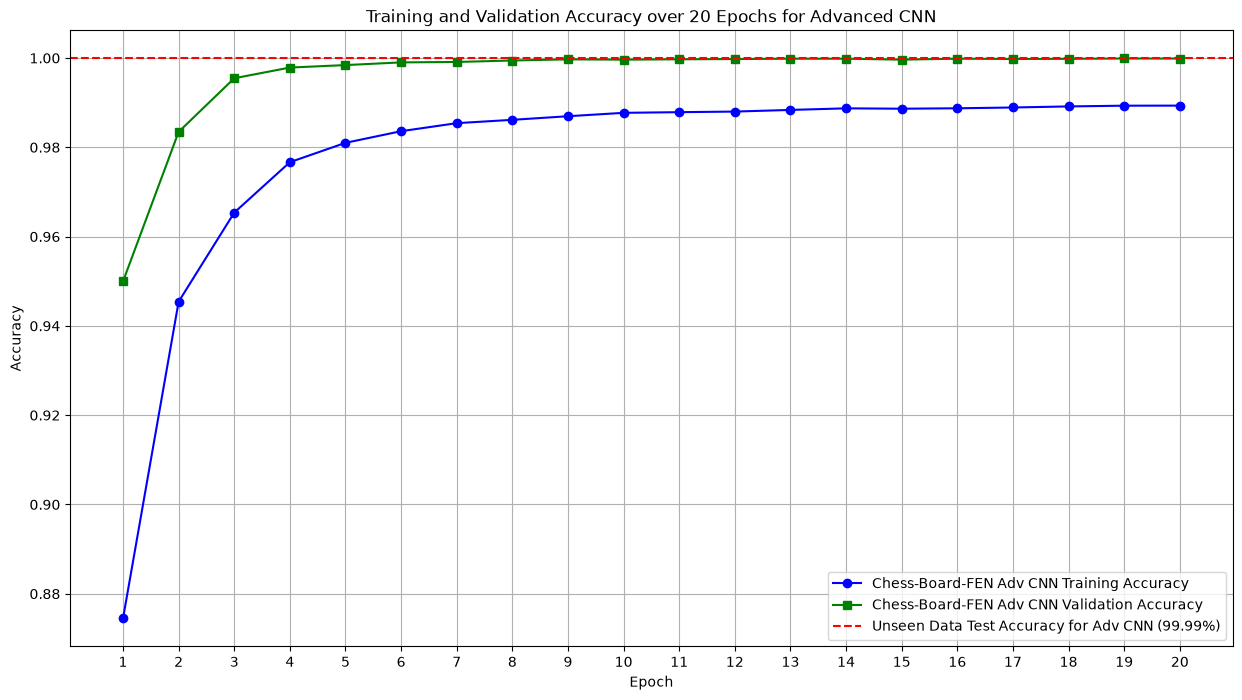

Final Recorded Test Accuracy: 99.99%


In [18]:
# Let's plot the accuracy over Epochs curve
plt.figure(figsize=(15, 8))
actual_epochs_adv = len(history_adv.history["accuracy"])
epochs_adv = range(1, actual_epochs_adv + 1)

plt.plot(
    epochs_adv,
    history_adv.history["accuracy"],
    "b-o",
    label="Chess-Board-FEN Adv CNN Training Accuracy"
)
plt.plot(
    epochs_adv,
    history_adv.history["val_accuracy"],
    "g-s",
    label="Chess-Board-FEN Adv CNN Validation Accuracy"
)

# The final test accuracy as a horizontal red dashed line
plt.axhline(
    y=test_accuracy_adv,
    color='r',
    linestyle='--',
    label=f"Unseen Data Test Accuracy for Adv CNN ({test_accuracy_adv*100:.2f}%)"
)

plt.title(f"Training and Validation Accuracy over {actual_epochs_adv} Epochs for Advanced CNN")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs_adv)
plt.legend()
plt.grid(True)
plt.show() # Ensure plot is shown

# Print summary recorded accuracies
print(f"Final Recorded Test Accuracy: {test_accuracy_adv * 100:.2f}%")

Observation
============
The Unseen Data Test accuracy is higher than the Training accuracy and the Validation accuracy. This was also observed in the base CNN model & reasons noted (recall 40% Dropout in the 1024 Dense Layer - the Dropouts deliberately drop the learnings/weights to avoid memorization).  

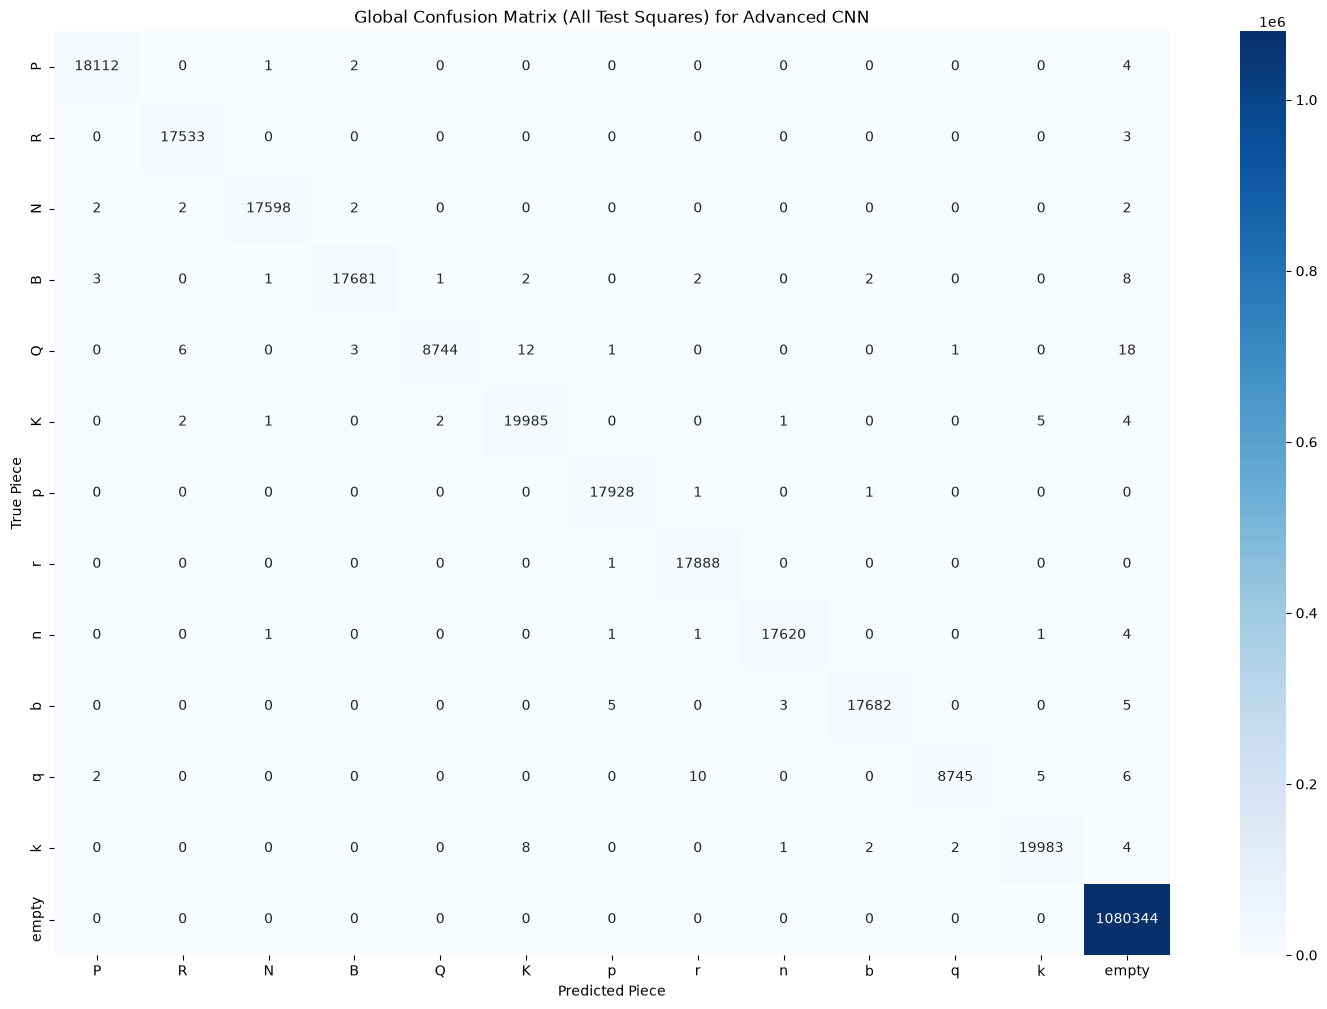


--- Per-Piece Accuracy Breakdown ---
     P : 99.96%  ( 18112 /  18119)
     R : 99.98%  ( 17533 /  17536)
     N : 99.95%  ( 17598 /  17606)
     B : 99.89%  ( 17681 /  17700)
     Q : 99.53%  (  8744 /   8785)
     K : 99.92%  ( 19985 /  20000)
     p : 99.99%  ( 17928 /  17930)
     r : 99.99%  ( 17888 /  17889)
     n : 99.95%  ( 17620 /  17628)
     b : 99.93%  ( 17682 /  17695)
     q : 99.74%  (  8745 /   8768)
     k : 99.91%  ( 19983 /  20000)
 empty : 100.00%  (1080344 / 1080344)


In [39]:
# Generate and Plot the confusion matrix for Advanced CNN Model
cm_adv = confusion_matrix(y_true_flat, y_pred_flat_adv)

plt.figure(figsize=(18, 12))
# Reusing the class_labels variable from earlier
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

plt.title('Global Confusion Matrix (All Test Squares) for Advanced CNN')
plt.xlabel('Predicted Piece')
plt.ylabel('True Piece')
plt.show()

print("\n--- Per-Piece Accuracy Breakdown ---")
# The diagonal contains the correct predictions for each class
correct_per_class = cm_adv.diagonal()
# Summing across the rows gives the total actual instances of each class
total_per_class = cm_adv.sum(axis=1)

# print per-piece accuracy
for idx, piece in enumerate(class_labels):
    if total_per_class[idx] > 0:
        acc = (correct_per_class[idx] / total_per_class[idx]) * 100
        # Format the output for clean alignment
        print(f"{piece:>6} : {acc:5.2f}%  ({correct_per_class[idx]:>6} / {total_per_class[idx]:>6})")
    else:
        print(f"{piece:>6} : N/A (0 instances in test set)")

In [40]:
# Let's Save the entire model (architecture + weights + optimizer state)
adv_cnn.save('advanced_chess_fen_cnn.keras')

Let's compare the 3 models using the precision, Recall and F1-Score metrics.
========================================

In [43]:
def plot_model_comparisons(mlp_model, cnn_model, adv_cnn_model, X_test, y_test, class_names):
    # 1. Prepare true labels (Flatten all 64 squares into a single 1D array)
    if len(y_test.shape) == 3: # In case it was one-hot encoded
        y_true = np.argmax(y_test, axis=-1).flatten()
    else:
        y_true = np.array(y_test).flatten()

    models = {
        "MLP": mlp_model,
        "Base CNN": cnn_model,
        "Advanced CNN": adv_cnn_model
    }

    # Dictionaries to store results
    overall_metrics = {'Precision': [], 'Recall': [], 'F1-Score': []}
    per_class_f1 = {name: [] for name in models.keys()}

    # 2. Calculate metrics for each model
    for name, model in models.items():
        print(f"Generating predictions for {name}...")
        raw_preds = model.predict(X_test, verbose=0)

        # Argmax to get the class prediction (0-12), then flatten to 1D to match y_true
        y_pred = np.argmax(raw_preds, axis=-1).flatten()

        # Get weighted averages for the overall plot
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
        overall_metrics['Precision'].append(precision)
        overall_metrics['Recall'].append(recall)
        overall_metrics['F1-Score'].append(f1)

        # Get per-class F1 scores for the detailed plot
        _, _, f1_per_class, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
        per_class_f1[name] = f1_per_class

    # 3. Create the Overall Metrics Plot (Grouped Bar Chart)
    x = np.arange(len(overall_metrics.keys()))  # [0, 1, 2] for Precision, Recall, F1
    width = 0.25  # Width of the bars

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

    # Plot bars for ax1
    ax1.bar(x - width, [overall_metrics[metric][0] for metric in overall_metrics], width, label='MLP', color='skyblue')
    ax1.bar(x, [overall_metrics[metric][1] for metric in overall_metrics], width, label='Base CNN', color='lightgreen')
    ax1.bar(x + width, [overall_metrics[metric][2] for metric in overall_metrics], width, label='Advanced CNN', color='salmon')

    # Formatting ax1
    ax1.set_ylabel('Score')
    ax1.set_title('Overall Model Comparison (Weighted Average)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(overall_metrics.keys())
    ax1.set_ylim(0, 1.1)
    ax1.legend()

    # Add text labels on top of the bars
    for p in ax1.patches:
        ax1.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=9)

    # 4. Create the Per-Class F1-Score Plot
    x_classes = np.arange(len(class_names))

    ax2.bar(x_classes - width, per_class_f1['MLP'], width, label='MLP', color='skyblue')
    ax2.bar(x_classes, per_class_f1['Base CNN'], width, label='Base CNN', color='lightgreen')
    ax2.bar(x_classes + width, per_class_f1['Advanced CNN'], width, label='Advanced CNN', color='salmon')

    # Formatting ax2
    ax2.set_ylabel('F1-Score')
    ax2.set_title('F1-Score by Piece Class')
    ax2.set_xticks(x_classes)
    ax2.set_xticklabels(class_names, rotation=45, ha='right')
    ax2.set_ylim(0, 1.1)
    ax2.legend(loc='lower right')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


Generating predictions for MLP...
Generating predictions for Base CNN...
Generating predictions for Advanced CNN...


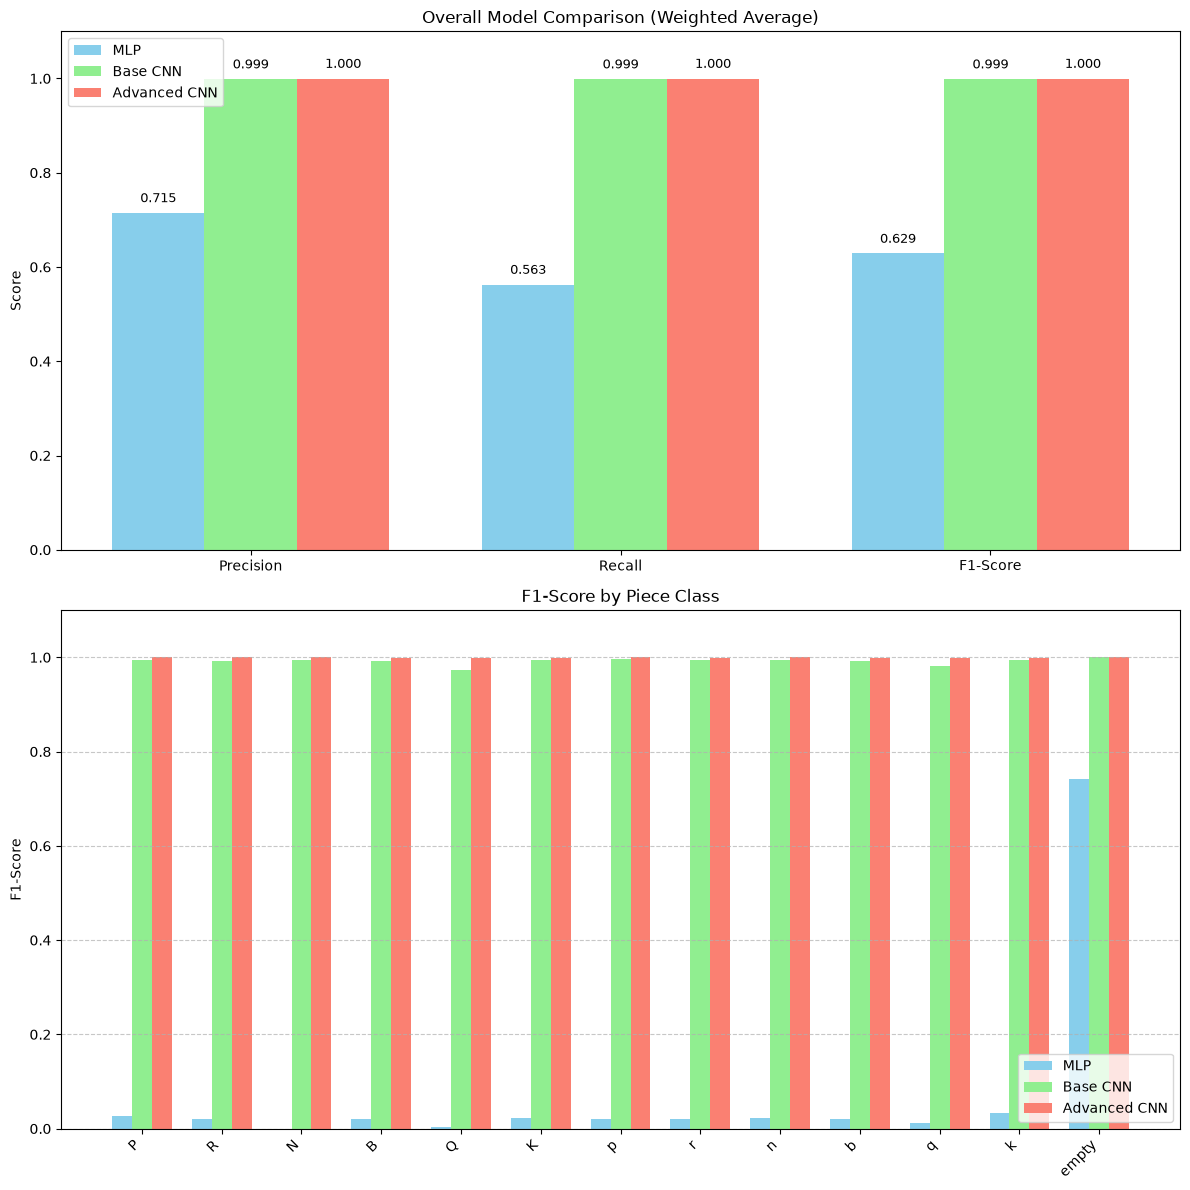

In [44]:
# Using the exact variables loaded in your Colab environment
plot_model_comparisons(full_board_mlp, cnn_model, adv_cnn, X_test, y_test_encoded, class_labels)

************** END OF MODELS *****************
============================

------------------------------

Let us now evaluate the Adv-CNN (and possibly other preveious models) on realworld Chess-Board Images!!
==================================


In [45]:
ADV_CNN_MODEL_FILE="/Users/mahidasp/Stanford-Courses/PythonTech-27/Project-Chess-FEN/src/advanced_chess_fen_cnn.keras"

In [46]:
#Reload the adv_cnn Model
adv_cnn = tf.keras.models.load_model(ADV_CNN_MODEL_FILE)

In [47]:
def extract_and_flatten_board_v0(image_path):
    # 1. Read the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read the image: {image_path}")

    # 2. Brute-force resize to exactly 200x200 (ignoring aspect ratio)
    resized_board = cv2.resize(img, (200, 200))

    # 3. Convert from OpenCV's default BGR to RGB for the CNN
    rgb_board = cv2.cvtColor(resized_board, cv2.COLOR_BGR2RGB)

    return rgb_board

In [48]:
# Helper Functions to ensure the image we present to the model is ordered
# correct (Top-Left, Top-Right, Bottom-Left, Bottom-Right)
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)] # Top-Left has the smallest sum
    rect[2] = pts[np.argmax(s)] # Bottom-Right has the largest sum
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)] # Top-Right has the smallest difference
    rect[3] = pts[np.argmax(diff)] # Bottom-Left has the largest difference
    return rect


# 2. The Computer Vision Preprocessor
def extract_and_flatten_board_v1(image_path):
    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Could not read the image. Check the file path.")

    # Convert to grayscale and blur
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Find edges
    edges = cv2.Canny(blurred, 50, 150)

    # Find all contours
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

    board_contour = None
    for c in contours:
        perimeter = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * perimeter, True)

        if len(approx) == 4:
            board_contour = approx.reshape(4, 2)
            break

    if board_contour is None:
        # FALLBACK: If we can't find an outer border, assume it is already a flat 2D diagram.
        print("  -> No outer border detected. Assuming image is already flat. Resizing directly...")
        warped_board = cv2.resize(img, (200, 200))
    else:
        # We found a border, apply the Perspective Transform
        rect = order_points(board_contour)
        dst = np.array([[0, 0], [199, 0], [199, 199], [0, 199]], dtype="float32")
        warp_matrix = cv2.getPerspectiveTransform(rect, dst)
        warped_board = cv2.warpPerspective(img, warp_matrix, (200, 200))

    # Convert BGR to RGB for the CNN
    warped_board = cv2.cvtColor(warped_board, cv2.COLOR_BGR2RGB)

    return warped_board


In [49]:
def extract_and_flatten_board_v2(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Could not read the image. Check the file path.")

    total_image_area = img.shape[0] * img.shape[1]

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]

    board_contour = None
    for c in contours:
        perimeter = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * perimeter, True)

        # Only accept the contour if it represents at least 40% of the entire image
        if len(approx) == 4 and cv2.contourArea(approx) > (total_image_area * 0.40):
            board_contour = approx.reshape(4, 2)
            break

    if board_contour is None:
        print("  -> No valid outer border detected. Assuming image is already flat.")
        # Shave 4% off coordinate borders (A-H, 1-8) before resizing
        h, w = img.shape[:2]
        crop_h, crop_w = int(h * 0.04), int(w * 0.04)
        cropped_img = img[crop_h:h-crop_h, crop_w:w-crop_w]
        warped_board = cv2.resize(cropped_img, (200, 200))
    else:
        rect = order_points(board_contour)
        dst = np.array([[0, 0], [199, 0], [199, 199], [0, 199]], dtype="float32")
        warp_matrix = cv2.getPerspectiveTransform(rect, dst)
        warped_board = cv2.warpPerspective(img, warp_matrix, (200, 200))

    return cv2.cvtColor(warped_board, cv2.COLOR_BGR2RGB)

In [50]:
def extract_and_flatten_board_v3(image_path, crop_percent=0.04):

    # Read the image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read the image: {image_path}")

    # Calculate how many pixels to shave off the edges
    height, width = img.shape[:2]
    crop_h = int(height * crop_percent)
    crop_w = int(width * crop_percent)

    # Crop the image using numpy slicing (removes top/bottom and left/right)
    # If crop_percent is 0, it just keeps the whole image
    if crop_percent > 0:
        img = img[crop_h:height-crop_h, crop_w:width-crop_w]

    # 4. Resize the cleanly cropped board to exactly 200x200
    resized_board = cv2.resize(img, (200, 200))

    # 5. Convert from OpenCV's default BGR to RGB for the CNN
    rgb_board = cv2.cvtColor(resized_board, cv2.COLOR_BGR2RGB)

    return rgb_board

In [51]:
# 3. The CNN Predictor
def predict_real_world_image(image_path, model):

    print("Extracting board using OpenCV...")
    # Determine crop factor directly from the image name
    file_name = os.path.basename(image_path)
    crop_factor = 0.04 if file_name == "image_2.jpeg" else 0.0

    # Read the original image just for the display plot
    orig_img_bgr = cv2.imread(image_path)
    if orig_img_bgr is not None:
        orig_img_rgb = cv2.cvtColor(orig_img_bgr, cv2.COLOR_BGR2RGB)

    #Extract and crop
    flat_board_img = extract_and_flatten_board_v3(image_path, crop_percent=crop_factor)


    # repare for the CNN (Normalize and add batch dimension)
    cnn_input = flat_board_img.astype('float32') / 255.0
    cnn_input = np.expand_dims(cnn_input, axis=0) # Changes shape from (200, 200, 3) to (1, 200, 200, 3)

    print("Running Advanced CNN Prediction...")
    # Predict
    raw_predictions = model.predict(cnn_input, verbose=0)
    class_indices = np.argmax(raw_predictions[0], axis=-1) # Get the highest probability for each of the 64 squares

    # Build the prediction text grid
    pred_text = "CNN PREDICTION:\n" + "-" * 33 + "\n"
    for row in range(8):
        row_str = "|"
        for col in range(8):
            square_idx = (row * 8) + col
            piece_code = class_indices[square_idx]
            piece_char = INT_TO_PIECE[piece_code]
            display_char = "." if piece_char == "empty" else piece_char
            row_str += f" {display_char} |"
        pred_text += row_str + "\n" + "-" * 33 + "\n"


    # Display dynamically based on whether it was cropped
    if crop_factor > 0:
        # Panels: Original | Cropped | Prediction
        fig, (ax_orig, ax_crop, ax_text) = plt.subplots(1, 3, figsize=(11, 4), gridspec_kw={'width_ratios': [1, 1, 1.2]})

        ax_orig.imshow(orig_img_rgb)
        ax_orig.set_title(f"Original: {file_name}", fontsize=10)
        ax_orig.axis('off')

        ax_crop.imshow(flat_board_img)
        ax_crop.set_title(f"Cropped ({crop_factor*100:.0f}%)", fontsize=10)
        ax_crop.axis('off')

        ax_text.axis('off')
        ax_text.text(0.1, 0.5, pred_text, fontsize=11, family='monospace', va='center', ha='left')

    else:
        # Panels: Processed | Prediction
        fig, (ax_img, ax_text) = plt.subplots(1, 2, figsize=(8, 4), gridspec_kw={'width_ratios': [1, 1.2]})

        ax_img.imshow(flat_board_img)
        ax_img.set_title(f"{file_name} (No Crop)", fontsize=10)
        ax_img.axis('off')

        ax_text.axis('off')
        ax_text.text(0.1, 0.5, pred_text, fontsize=11, family='monospace', va='center', ha='left')

    plt.tight_layout()
    plt.show()

In [52]:
# Real-world Images Path
REAL_WORLD_IMAGES_PATH="/Users/mahidasp/Downloads/chess_real_world_images/"


In [53]:
def predict_all_real_world_images(directory_path, model):
    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".avif"}
    dir_path = Path(directory_path)

    if not dir_path.exists() or not dir_path.is_dir():
        print(f"Error: Directory '{directory_path}' does not exist.")
        return

    # Find and sort all image files in the target folder
    image_files = sorted([
        f for f in dir_path.iterdir()
        if f.suffix.lower() in valid_extensions and not f.name.startswith(".")
    ])

    if not image_files:
        print(f"No valid image files found in '{directory_path}'.")
        return

    print(f"Found {len(image_files)} images. Starting batch inference...\n")

    for i, img_path in enumerate(image_files, start=1):
        print(f"{'='*50}")
        print(f"[{i}/{len(image_files)}] Processing: {img_path.name}")
        print(f"{'='*50}")

        try:
            predict_real_world_image(str(img_path), model)
        except Exception as e:
            print(f"Skipping {img_path.name}: {e}\n")

Found 6 images. Starting batch inference...

[1/6] Processing: image_1.jpeg
Extracting board using OpenCV...
Running Advanced CNN Prediction...


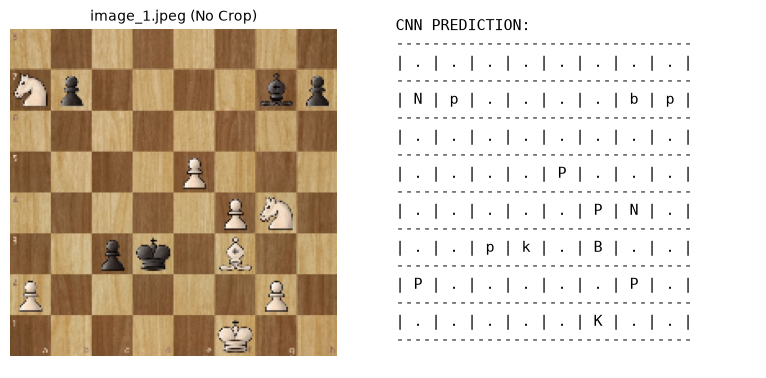

[2/6] Processing: image_2.jpeg
Extracting board using OpenCV...
Running Advanced CNN Prediction...


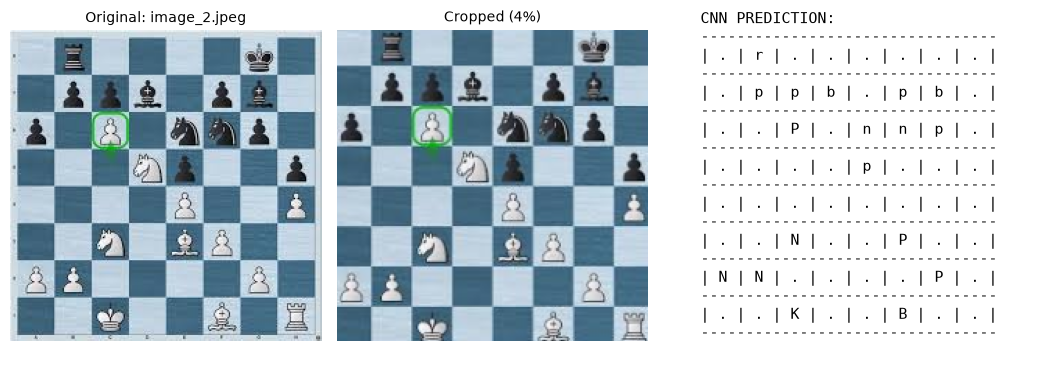

[3/6] Processing: image_3.png
Extracting board using OpenCV...
Running Advanced CNN Prediction...


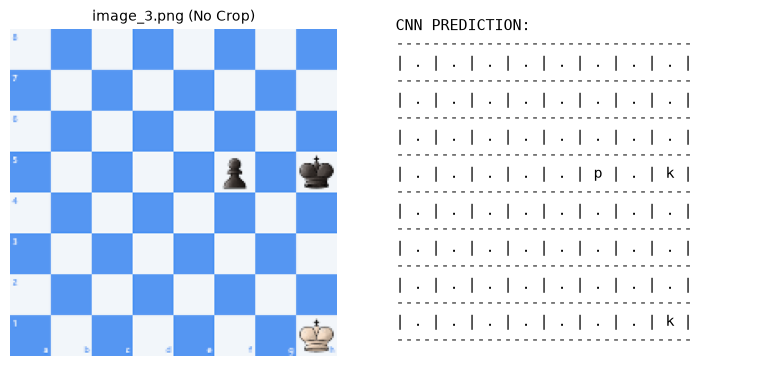

[4/6] Processing: image_4.png
Extracting board using OpenCV...
Running Advanced CNN Prediction...


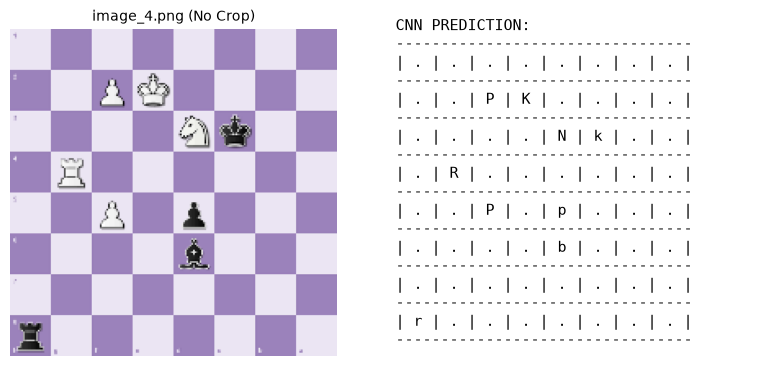

[5/6] Processing: image_5.jpg
Extracting board using OpenCV...
Running Advanced CNN Prediction...


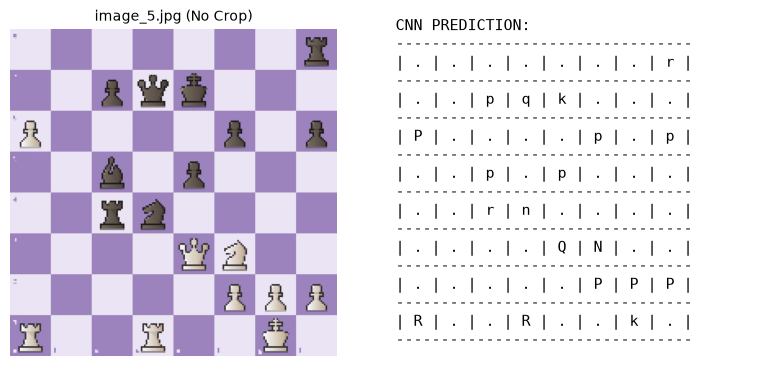

[6/6] Processing: image_6.jpeg
Extracting board using OpenCV...
Running Advanced CNN Prediction...


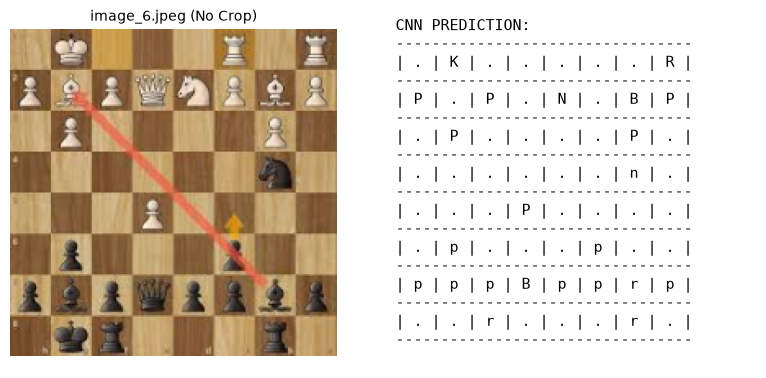

In [54]:
# --- Usage ---
# REAL_WORLD_IMAGES_PATH = "./real_world_images"
predict_all_real_world_images(REAL_WORLD_IMAGES_PATH, adv_cnn)

END
===